In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
tickers = ['SPY', 'AGG', 'GLD']

weights = {
    'SPY': 0.60,  # 60% US equities
    'AGG': 0.30,  # 30% US aggregate bonds
    'GLD': 0.10   # 10% gold
}

In [3]:
data = yf.download(tickers, start='2025-01-01', end='2026-01-01')['Close']
data.head()


[*********************100%***********************]  3 of 3 completed


Ticker,AGG,GLD,SPY
Date,,,
2025-01-02,92.282120,245.419998,576.280334
2025-01-03,92.186890,243.490005,583.485840
2025-01-06,92.091660,243.190002,586.847046
2025-01-07,91.767899,244.559998,580.213257
2025-01-08,91.872650,245.860001,581.060974


In [4]:
daily_returns = data.pct_change().dropna()

weights_series = pd.Series(weights)
portfolio_returns = (daily_returns * weights_series).sum(axis=1)

cumulative_return = (1 + portfolio_returns).cumprod()
cumulative_return.tail()

Date
2025-12-24    1.204253
2025-12-26    1.205658
2025-12-29    1.198266
2025-12-30    1.197332
2025-12-31    1.190374
dtype: float64

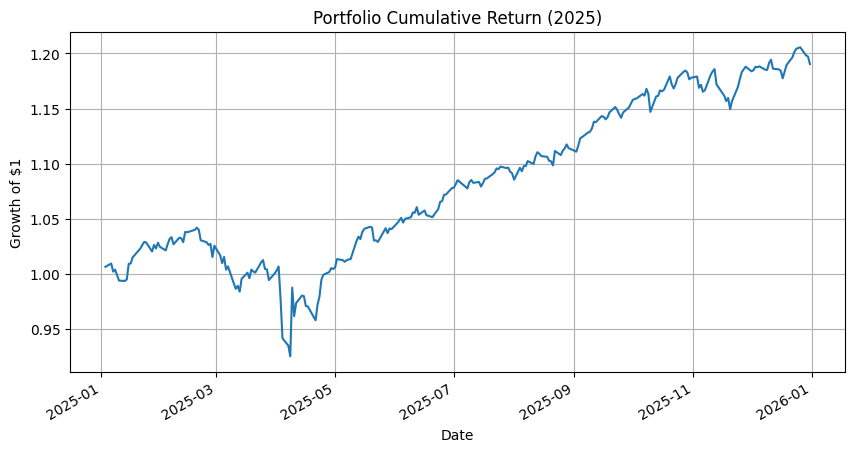

In [5]:
cumulative_return.plot(figsize=(10, 5), title='Portfolio Cumulative Return (2025)')
plt.ylabel('Growth of $1')
plt.xlabel('Date')
plt.grid(True)
plt.show()


In [6]:
daily_returns.head()

Ticker,AGG,GLD,SPY
Date,,,
2025-01-03,-0.001032,-0.007864,0.012503
2025-01-06,-0.001033,-0.001232,0.005761
2025-01-07,-0.003516,0.005633,-0.011304
2025-01-08,0.001141,0.005316,0.001461
2025-01-10,-0.005597,0.009558,-0.015267


In [8]:
(daily_returns * weights_series).head()

Ticker,AGG,GLD,SPY
Date,,,
2025-01-03,-0.000310,-0.000786,0.007502
2025-01-06,-0.000310,-0.000123,0.003456
2025-01-07,-0.001055,0.000563,-0.006782
2025-01-08,0.000342,0.000532,0.000877
2025-01-10,-0.001679,0.000956,-0.009160


In [10]:
weights_typo = pd.Series({'SPY': 0.60, 'AGG': 0.30, 'GOLD': 0.10})
(daily_returns * weights_typo).head()


Ticker,AGG,GLD,GOLD,SPY
Date,,,,
2025-01-03,-0.000310,NaN,NaN,0.007502
2025-01-06,-0.000310,NaN,NaN,0.003456
2025-01-07,-0.001055,NaN,NaN,-0.006782
2025-01-08,0.000342,NaN,NaN,0.000877
2025-01-10,-0.001679,NaN,NaN,-0.009160
